<a href="https://colab.research.google.com/github/martush/martush_notebooks/blob/develop/Char_Level_Language_Model_MLP_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bulding on top of the previously created MLP but focusing on activations, gradients and batchnorm

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-03-17 12:22:53--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.07s   

2026-03-17 12:22:53 (3.32 MB/s) - ‘names.txt’ saved [228145/228145]



In [3]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [5]:
#build vocabulary of all chars and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [6]:
#build dataset
block_size = 3 #context length - how many input chars to predict next

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '---->', itos[ix])
            context = context[1:] + [ix] #crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])  # 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # 10%
Xte, Yte = build_dataset(words[n2:]) # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [7]:
# Initialize all parameters

# MLP - without the magic numbers (hardcoded numbers)
n_emb = 10 # the dimensionality of the char embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
#lookup table
C = torch.randn((vocab_size, n_emb),  generator=g)

#hidden layer
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)

#output layer
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [8]:
Xtr.shape[0]

182625

In [9]:
C.shape

torch.Size([27, 10])

In [10]:
batch_size = 32
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
ix

tensor([  1680, 115963,  46562, 106512, 133208,   8221, 157987, 166078, 111909,
        122447,  52633, 175961, 174998,  64911, 129420,  75894, 132737, 148901,
         17679, 138048,  41303, 172668,  92710,  63166,  19022, 124158,  70538,
        104798,  40266, 181777,  96788,  61850])

In [11]:
Xtr[ix]

tensor([[ 4,  5, 23],
        [18, 14, 21],
        [12, 12, 25],
        [ 5,  5,  3],
        [ 5, 12,  5],
        [12, 25,  7],
        [ 0, 16, 18],
        [ 0,  0,  0],
        [ 0,  0,  8],
        [ 9, 25,  1],
        [12, 15, 14],
        [ 0,  1, 12],
        [ 8,  9, 14],
        [14, 15, 14],
        [24, 20,  9],
        [ 2,  1, 25],
        [12,  1,  8],
        [14,  9, 14],
        [ 1, 23, 19],
        [ 0,  0,  0],
        [ 1, 14,  4],
        [ 0,  0, 13],
        [18,  9,  5],
        [15, 14, 19],
        [ 0, 25,  9],
        [ 0,  0,  3],
        [15, 20,  9],
        [ 0,  0,  5],
        [ 0, 25, 21],
        [ 0,  0,  0],
        [ 0,  0, 12],
        [ 0,  0,  0]])

In [12]:
C

tensor([[ 1.5674e+00, -2.3729e-01, -2.7385e-02, -1.1008e+00,  2.8588e-01,
         -2.9643e-02, -1.5471e+00,  6.0489e-01,  7.9136e-02,  9.0462e-01],
        [-4.7125e-01,  7.8682e-01, -3.2843e-01, -4.3297e-01,  1.3729e+00,
          2.9334e+00,  1.5618e+00, -1.6261e+00,  6.7716e-01, -8.4039e-01],
        [ 9.8488e-01, -1.4837e-01, -1.4795e+00,  4.4830e-01, -7.0730e-02,
          2.4968e+00,  2.4448e+00, -6.7006e-01, -1.2199e+00,  3.0314e-01],
        [-1.0725e+00,  7.2762e-01,  5.1114e-02,  1.3095e+00, -8.0220e-01,
         -8.5042e-01, -1.8068e+00,  1.2523e+00, -1.2256e+00,  1.2165e+00],
        [-9.6478e-01, -2.3211e-01, -3.4762e-01,  3.3244e-01, -1.3263e+00,
          1.1224e+00,  5.9641e-01,  4.5846e-01,  5.4011e-02, -1.7400e+00],
        [ 1.1560e-01,  8.0319e-01,  5.4108e-01, -1.1646e+00,  1.4756e-01,
         -1.0006e+00,  3.8012e-01,  4.7328e-01, -9.1027e-01, -7.8305e-01],
        [ 1.3506e-01, -2.1161e-01, -1.0406e+00, -1.5367e+00,  9.3743e-01,
         -8.8303e-01,  1.7457e+0

In [13]:
C[Xtr[ix]]

tensor([[[-9.6478e-01, -2.3211e-01, -3.4762e-01,  3.3244e-01, -1.3263e+00,
           1.1224e+00,  5.9641e-01,  4.5846e-01,  5.4011e-02, -1.7400e+00],
         [ 1.1560e-01,  8.0319e-01,  5.4108e-01, -1.1646e+00,  1.4756e-01,
          -1.0006e+00,  3.8012e-01,  4.7328e-01, -9.1027e-01, -7.8305e-01],
         [-1.0527e+00, -1.4367e-01, -2.7737e-01,  1.1634e+00, -6.6910e-01,
           6.4918e-01,  5.8243e-01,  1.9264e+00, -3.7846e-01,  7.9577e-03]],

        [[ 1.2815e+00, -6.3182e-01, -1.2464e+00,  6.8305e-01, -3.9455e-01,
           1.4388e-02,  5.7216e-01,  8.6726e-01,  6.3149e-01, -1.2230e+00],
         [ 4.6827e-01, -6.5650e-01,  6.1662e-01, -6.2197e-01,  5.1007e-01,
           1.3563e+00,  2.3445e-01, -4.5585e-01, -1.3132e-03, -5.1161e-01],
         [-2.4780e-01,  8.8282e-01, -8.1004e-02, -9.5299e-01, -4.8838e-01,
          -7.3712e-01,  7.0609e-01, -1.9295e-01,  1.2348e+00,  3.3308e-01]],

        [[-5.6144e-01, -1.3753e-01, -1.3799e-01, -2.0977e+00, -7.9238e-01,
           6.06

In [14]:
from torch.func import grad
max_steps = 200000
batch_size = 32
lossi = []


for i in range(max_steps):

    #minibatch construct - random integer between 0 and size of training set - 32 of them
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concat the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # tracк stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())



      0/ 200000: 24.6599
  10000/ 200000: 2.1567
  20000/ 200000: 2.2152
  30000/ 200000: 2.0572
  40000/ 200000: 2.4419
  50000/ 200000: 2.2359
  60000/ 200000: 2.2655
  70000/ 200000: 2.7937
  80000/ 200000: 2.5044
  90000/ 200000: 2.3105
 100000/ 200000: 2.3744
 110000/ 200000: 1.8730
 120000/ 200000: 2.1928
 130000/ 200000: 1.9278
 140000/ 200000: 1.7563
 150000/ 200000: 2.4365
 160000/ 200000: 2.1674
 170000/ 200000: 1.7833
 180000/ 200000: 1.9442
 190000/ 200000: 2.1969


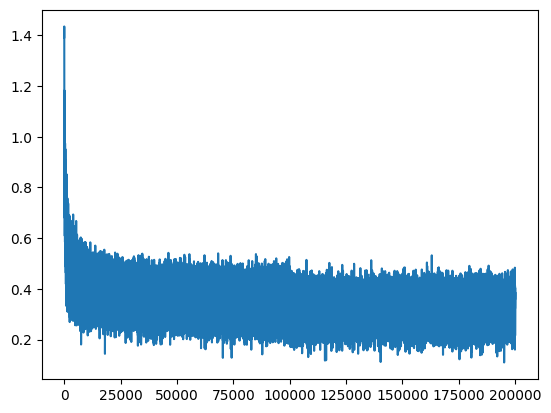

In [15]:
plt.plot(lossi);

In [16]:
@torch.no_grad() # the decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train' : (Xtr, Ytr),
        'val'   : (Xdev, Ydev),
        'test'  : (Xte, Yte),
    }[split]

    emb = C[x] # (N, block_size, n_emb)
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1084914207458496
val 2.1584315299987793


## Fixing initialization
The network is very improperly configured at initialization - multiple things wrong it it. The hockeye shape of the loss (27 on the first few iterations before it squashed params) are wrong.

Usually you have some rough idea on the loss you're expecting (depending on the problem setup and loss function) - in our case it would be 1/27 - at initialization we don't expect any character to be much more likely than anothe one, prob distribution should be uniform with equal probability
-torch.tensor(1/27.0).log() = 3.29 - much lower than 27

At initialization the probability distributions are all messed up - the network is very confidently wrong

In [17]:
#Small example of the issue
logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
probs = torch.softmax(logits, dim=0)
#for example label 2 is correct
loss = -probs[2].log()
probs, loss

(tensor([0.2500, 0.2500, 0.2500, 0.2500]), tensor(1.3863))

In [18]:
# We might luck out and the correct number is high - so very low loss
logits = torch.tensor([0.0, 0.0, 5.0, 0.0])
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
probs, loss

(tensor([0.0066, 0.0066, 0.9802, 0.0066]), tensor(0.0200))

In [21]:
# More likely though other dimensions will have high logit
#logits = torch.tensor([-3.0, 5.0, 0.0, 0.0])
logits = torch.randn(4)
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits, probs, loss

(tensor([-0.8415,  1.3419, -0.9333,  0.6137]),
 tensor([0.0663, 0.5889, 0.0605, 0.2843]),
 tensor(2.8048))

We want the logits to be roughly 0 at initialization. They don't have to be 0 - they just need to be equal - if they are all 1, it will work again but ideally around 0.

In [22]:
# Initialize all parameters
n_emb = 10 # the dimensionality of the char embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb),  generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [23]:
from torch.func import grad
max_steps = 200000
batch_size = 32
lossi = []


for i in range(max_steps):

    #minibatch construct - random integer between 0 and size of training set - 32 of them
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concat the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # tracк stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    break

      0/ 200000: 27.8817


In [24]:
# very extreme values
logits[0]

tensor([ -2.3527,  36.4366, -10.7306,   5.7165,  18.6409, -11.6998,  -2.1991,
          1.8535,  10.9996,  10.6730,  12.3507, -10.3809,   4.7243, -24.4257,
         -8.5909,   1.9024, -12.2744, -12.4751, -23.2778,  -2.0163,  25.8767,
         14.2108,  17.7691, -10.9204, -20.7335,   6.4560,  11.1615],
       grad_fn=<SelectBackward0>)

### Fix

How can we achieve logits coming out that are coming out closer to 0 and uniform?

In [28]:
# Initialize all parameters
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb),  generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
# Scale W2 down
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
# Initialize output layer biases to 0
b2 = torch.randn(vocab_size, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [29]:
from torch.func import grad
max_steps = 200000
batch_size = 32
lossi = []


for i in range(max_steps):

    #minibatch construct - random integer between 0 and size of training set - 32 of them
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concat the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # tracк stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3221
  10000/ 200000: 2.1900
  20000/ 200000: 2.4196
  30000/ 200000: 2.6067
  40000/ 200000: 2.0601
  50000/ 200000: 2.4988
  60000/ 200000: 2.3902
  70000/ 200000: 2.1344
  80000/ 200000: 2.3369
  90000/ 200000: 2.1299
 100000/ 200000: 1.8329
 110000/ 200000: 2.2053
 120000/ 200000: 1.8540
 130000/ 200000: 2.4566
 140000/ 200000: 2.1879
 150000/ 200000: 2.1118
 160000/ 200000: 1.8956
 170000/ 200000: 1.8644
 180000/ 200000: 2.0326
 190000/ 200000: 1.8417


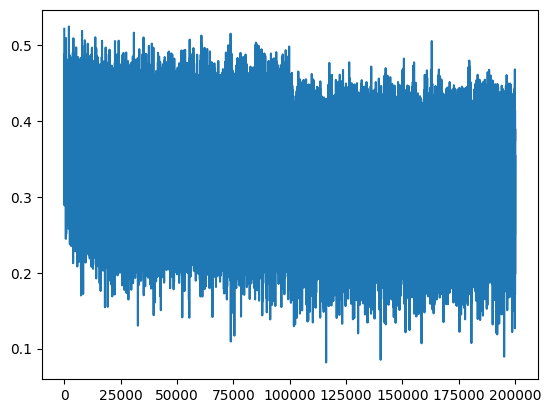

In [30]:
plt.plot(lossi);

In [31]:
@torch.no_grad() # the decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train' : (Xtr, Ytr),
        'val'   : (Xdev, Ydev),
        'test'  : (Xte, Yte),
    }[split]

    emb = C[x] # (N, block_size, n_emb)
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0695888996124268
val 2.1310746669769287


Why can't we just set W2 to 0 - then we'd get exactly what we're expecting at initialization (3.29 loss). You usually don't want to set weights to 0 - low but not 0.

You don't want the hockey stick shape of the loss - the first few iterations the optimization is squashing and then rerranging the logits. We take away that easy part and get the actual gains.

And the final loss we get is also improved.

## Fixing the saturated tanh

In [32]:
# Initialize all parameters
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb),  generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
# Scale W2 down
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
# Initialize output layer biases to 0
b2 = torch.randn(vocab_size, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [33]:
from torch.func import grad
max_steps = 200000
batch_size = 32
lossi = []


for i in range(max_steps):

    #minibatch construct - random integer between 0 and size of training set - 32 of them
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concat the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # tracк stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    break

      0/ 200000: 3.3221


While things look good, there is a deeper problem lurking.
Logits are ok, problem is values of h - the activations of the hidden state.

Tanh (the activation function) is a squashing function - takes arbitrary numbers and squashes them smoothly between -1 and 1.

In [34]:
# Note how many elements are 1/-1
h

tensor([[ 0.8100, -0.8997, -0.9993,  ..., -0.9097, -1.0000,  1.0000],
        [-1.0000, -0.9571, -0.7145,  ...,  0.4898,  0.9090,  0.9937],
        [ 0.9983, -0.3340,  1.0000,  ...,  0.9443,  0.9905,  1.0000],
        ...,
        [-1.0000,  0.9604, -0.1418,  ..., -0.1266,  1.0000,  1.0000],
        [-1.0000, -0.4385, -0.8882,  ..., -0.3316,  0.9995,  1.0000],
        [-1.0000,  0.9604, -0.1418,  ..., -0.1266,  1.0000,  1.0000]],
       grad_fn=<TanhBackward0>)

In [35]:
h.shape

torch.Size([32, 200])

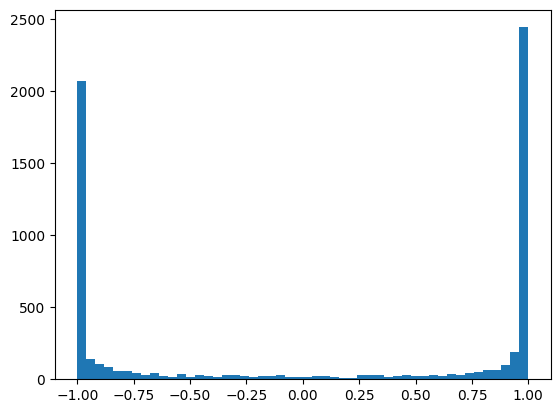

In [37]:
# Stretch it out into one large vector
plt.hist(h.view(-1).tolist(), 50);

The tanh is very very active - most values are -1 and 1. Lets look at the pre-activations that feed into the tanh.

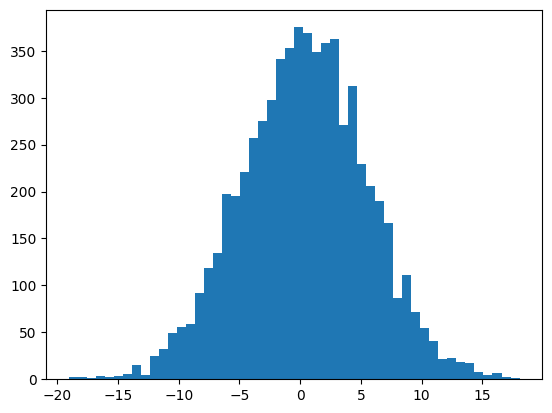

In [38]:
plt.hist(hpreact.view(-1).tolist(), 50);

Range is quite wide so a lot of numbers are being sqashed.

During backpropagation we're doing backward pass starting at the loss and flowing through the network backwards. In particular we are backpropagating through the tanh. This layer is made up of 200 neurons for each example.

t = (math.exp(2*x)-1/(math.exp(2*x)+1)

grad += (1- t**2) * out.grad

What happens if outputs are very close to -1 or 1? If you plug in 1 in the gradient, you get 0 * out.grad - no matter what out.grad is we're killing the gradient and effectively stopping the backpropagation through this unit. Similarly - if t = -1, same resul and out.grad just stops

https://www.medcalc.org/en/manual/functions/tanh.png

Intuitively, when at -1/1, it's on the tail ends which are very flat - changing the input, won't change the input a lot since it's flat.

If t is 0, 1 * out.grad - the gradient just passes through.

The more you are in the flat tails, the more it's squashed.

In fact, a gradient can only ever decrease when passing through the tanh -

The concern then if all these outputs h are in the flat region of -1/1, the gradients flowing through the network will just get destroyed here.

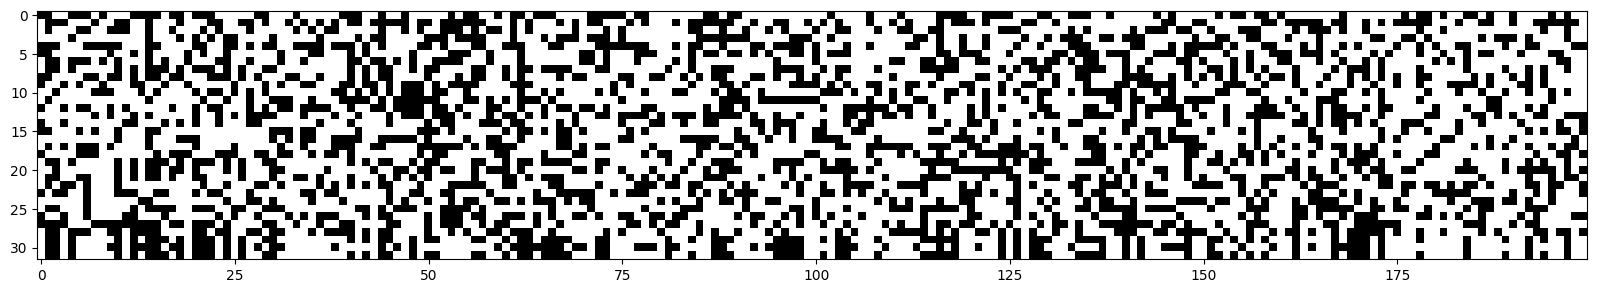

In [39]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest') #white if true

A lot of this is white - a lot of tanh neurons are active are in the flat tail. In all these cases gradient gets destroyed.

In a lot of trouble if for any of those 200 neurons the whole column is white - dead neuron (no single example ever activates the tanh). The neuron will never learn.

We don't have such cases.

In [16]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(itos[i] for i in out)) # decode and print the generated word